In [1]:
import pandas as pd
df = pd.read_csv("Weather_Integrated_Dataset.csv")
# 1. Ensure the 'Datetime' column is formatted as actual pandas datetime objects
df['Datetime'] = pd.to_datetime(df['Datetime'])

# 2. Filter the dataframe to keep only rows >= your target start time
start_time = '2026-06-22 12:48:00'
df = df[df['Datetime'] >= start_time]

# 3. Reset the index so your row numbers start cleanly at 0 again
df = df.reset_index(drop=True)

# Verify the result
df.head()

,Datetime,Hour,DayName,Weekend,DayOfWeek,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed
0,2026-06-22 12:48:05,12,Monday,0,0,24.8,65.0,26.380000,91.34115,0.0,98.200000,3.898234
1,2026-06-22 12:49:05,12,Monday,0,0,24.8,64.5,26.369167,91.42090,0.0,98.183334,3.873381
2,2026-06-22 12:50:05,12,Monday,0,0,24.9,63.9,26.358334,91.50064,0.0,98.166664,3.848528
3,2026-06-22 12:51:05,12,Monday,0,0,24.9,63.4,26.347500,91.58039,0.0,98.150000,3.823675
4,2026-06-22 12:52:05,12,Monday,0,0,24.9,62.8,26.336666,91.66014,0.0,98.133330,3.798822


In [2]:
import pandas as pd

# 1. Ensure Datetime is a proper datetime object and set it as the index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# 2. Isolate only the continuous numerical columns that make sense to average
numerical_cols = [
    'IndoorTemp', 'IndoorHumidity', 
    'OutdoorTemp', 'OutdoorHumidity', 
    'Rain', 'CloudCover', 'WindSpeed'
]

# 3. Downsample to 5-minute chunks ('5min') and calculate the mean
df_5min = df[numerical_cols].resample('5min').mean()

# Drop any blank rows (in case there were missing chunks in your original data)
df_5min = df_5min.dropna()

# 4. Rebuild the time and calendar features based on the new 5-minute timestamps
df_5min['Hour'] = df_5min.index.hour
df_5min['DayOfWeek'] = df_5min.index.dayofweek # Monday=0, Sunday=6
df_5min['DayName'] = df_5min.index.day_name()
df_5min['Weekend'] = df_5min['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# 5. Reset the index so 'Datetime' becomes a normal column again
df_5min = df_5min.reset_index()

# Check the results
df_5min.head()

,Datetime,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed,Hour,DayOfWeek,DayName,Weekend
0,2026-06-22 12:45:00,24.80,64.75,26.374583,91.381025,0.0,98.191667,3.885807,12,0,Monday,0
1,2026-06-22 12:50:00,24.86,63.02,26.336666,91.660136,0.0,98.133333,3.798822,12,0,Monday,0
2,2026-06-22 12:55:00,24.70,61.68,26.282500,92.058876,0.0,98.050000,3.674558,12,0,Monday,0
3,2026-06-22 13:00:00,24.62,62.90,26.238333,92.362474,0.0,97.766666,3.607138,13,0,Monday,0
4,2026-06-22 13:05:00,24.66,62.20,26.209167,92.523360,0.0,97.183333,3.624982,13,0,Monday,0


Labeling

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

# Calculate rate of change for temperature and humidity
df_5min['dT'] = df_5min['IndoorTemp'].diff().fillna(0)
df_5min['dH'] = df_5min['IndoorHumidity'].diff().fillna(0)

# Calculate the Thermal Gradient
df_5min['Gradient'] = df_5min['OutdoorTemp'] - df_5min['IndoorTemp']

# ==========================================
# 2. SCHEDULE MASKING & K-MEANS CLUSTERING
# ==========================================
# Default everything to OFF (0) initially
df_5min['AC_State'] = 0 

# Define active business hours for the initial ML guess
active_days = df_5min['DayOfWeek'].isin([0, 2, 4])
active_hours = (df_5min['Hour'] >= 9) & (df_5min['Hour'] < 18)
uncertain_mask = active_days & active_hours

# Run K-Means only on the uncertain times
uncertain_data = df_5min[uncertain_mask].copy()
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
features = ['dT', 'dH', 'Gradient']
uncertain_data['cluster'] = kmeans.fit_predict(uncertain_data[features])

# Identify the AC ON cluster (steepest temperature drop)
on_cluster_index = np.argmin(kmeans.cluster_centers_[:, 0]) 
uncertain_data['Predicted_AC'] = (uncertain_data['cluster'] == on_cluster_index).astype(int)

# Map ML predictions back to the main dataframe
df_5min.loc[uncertain_mask, 'AC_State'] = uncertain_data['Predicted_AC']

# ==========================================
# 3. THE FIX: ROBUST PHYSICS OVERRIDES
# ==========================================
# Override A: The Thermodynamic Limit (Accounts for DHT22 and API Error)
# 1. Widen the margin to 2.5°C to survive sensor inaccuracies.
is_colder_than_outside = df_5min['IndoorTemp'] < (df_5min['OutdoorTemp'] - 2.5)
# 2. Prevent morning thermal lag from causing false positives.
is_not_warming = df_5min['dT'] <= 0.05 
temp_override = is_colder_than_outside & is_not_warming

# Override B: Rapid Mechanical Cooling Threshold
# A drop faster than -0.15°C in 5 minutes is mathematically impossible without an AC.
cooling_override = df_5min['dT'] < -0.15

# Apply the overrides: Force AC_State to 1 regardless of the schedule or ML
df_5min.loc[temp_override | cooling_override, 'AC_State'] = 1

# Override C: The Thermodynamic Kill Switch (Negative Override)
# If the temperature is actively rising by more than 0.05°C per 5 mins, 
# the AC is definitively OFF, regardless of what K-Means predicted.
warming_override = df_5min['dT'] > 0.05
df_5min.loc[warming_override, 'AC_State'] = 0

# ==========================================
# 4. MECHANICAL SMOOTHING & CLEANUP
# ==========================================
# Apply a 15-minute rolling median (window=3) to fix flickering/sensor noise
df_5min['AC_State'] = df_5min['AC_State'].rolling(window=7, center=True).median()
df_5min['AC_State'] = df_5min['AC_State'].fillna(0).astype(int)

# Drop calculation columns we no longer need to keep the final dataframe clean
df_final = df_5min.drop(columns=['Hour', 'DayOfWeek', 'dT', 'dH', 'Gradient']).reset_index()

# Output the final results
print("Robust Labeling Complete! Final AC State breakdown (in 5-min intervals):")
print(df_final['AC_State'].value_counts())

Robust Labeling Complete! Final AC State breakdown (in 5-min intervals):
AC_State
0    1516
1     509
Name: count, dtype: int64


Visualization

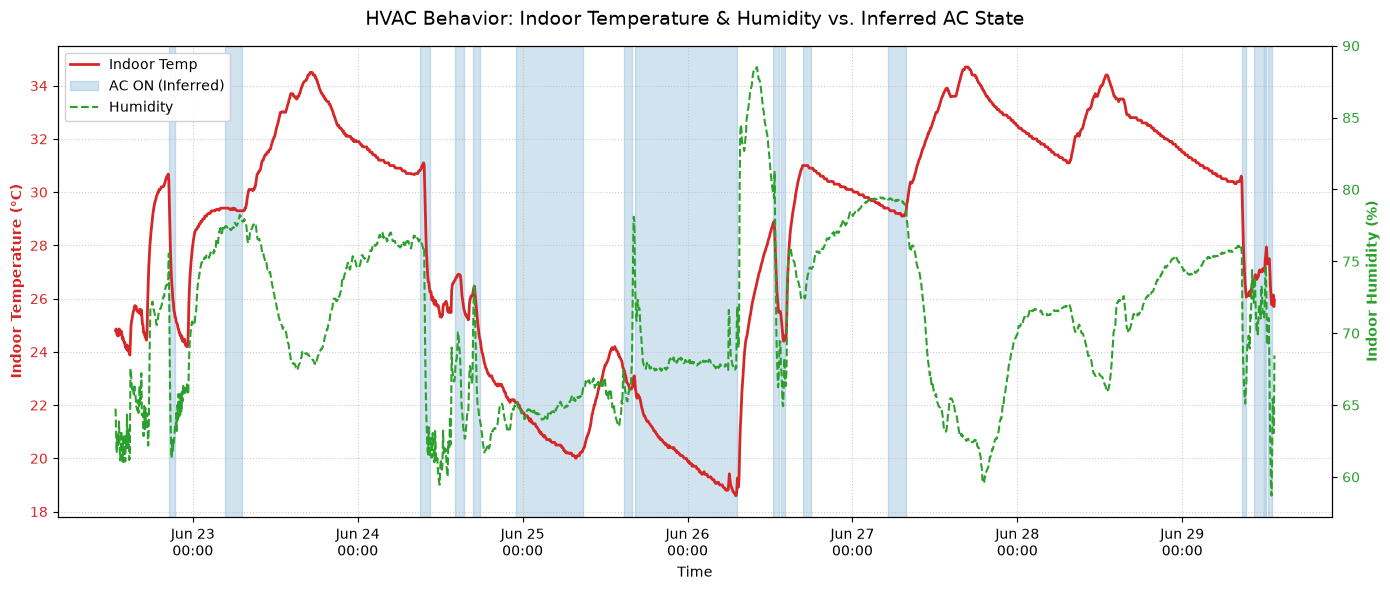

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure Datetime is the index for plotting
if 'Datetime' in df_final.columns:
    df_plot = df_final.set_index('Datetime')
else:
    df_plot = df_final.copy()

# Filter a 2-day window to make the chart readable 
# (Plotting 7 full days on one chart squashes the lines too much)
# Adjust these dates based on the actual dates in your dataset
start_date = '2026-06-22 00:00:00'
end_date = '2026-06-29 23:59:59'
df_subset = df_plot.loc[start_date:end_date]

# Create the plot figure
fig, ax1 = plt.subplots(figsize=(14, 6))

# 1. Plot the Indoor Temperature
color1 = 'tab:red'
ax1.set_xlabel('Time')
ax1.set_ylabel('Indoor Temperature (°C)', color=color1, fontweight='bold')
ax1.plot(df_subset.index, df_subset['IndoorTemp'], color=color1, linewidth=2, label='Indoor Temp')
ax1.tick_params(axis='y', labelcolor=color1)

# 2. Plot the Indoor Humidity on a secondary Y-axis
ax2 = ax1.twinx()  
color2 = 'tab:green'
ax2.set_ylabel('Indoor Humidity (%)', color=color2, fontweight='bold')
ax2.plot(df_subset.index, df_subset['IndoorHumidity'], color=color2, linewidth=1.5, linestyle='--', label='Humidity')
ax2.tick_params(axis='y', labelcolor=color2)

# 3. Highlight the background when the AC is ON (Predicted_AC = 1)
# This fills the background vertically wherever the AC_State column equals 1
ax1.fill_between(
    df_subset.index, 
    0, 1, 
    where=(df_subset['AC_State'] == 1), 
    color='tab:blue', 
    alpha=0.2, 
    transform=ax1.get_xaxis_transform(),
    label='AC ON (Inferred)'
)

# 4. Formatting and aesthetics
plt.title('HVAC Behavior: Indoor Temperature & Humidity vs. Inferred AC State', fontsize=14, pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)

# Format the x-axis to show days and hours cleanly
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.xticks(rotation=0)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# Assume df_final is your labeled 5-minute dataset
# Ensure Datetime is a column, not just the index
if 'Datetime' not in df_final.columns:
    df_final = df_final.reset_index()

# 1. Create a unique ID for every continuous block of AC states
# This increments the ID by 1 every time the AC switches from ON to OFF or OFF to ON
df_final['Cycle_ID'] = (df_final['AC_State'] != df_final['AC_State'].shift()).cumsum()

# 2. Filter to look ONLY at the periods where the AC was ON
on_cycles = df_final[df_final['AC_State'] == 1]

# 3. Group by the Cycle_ID to calculate the stats for each continuous run
diagnostics = on_cycles.groupby('Cycle_ID').agg(
    Start_Time=('Datetime', 'first'),
    End_Time=('Datetime', 'last'),
    Start_Temp=('IndoorTemp', 'first'),
    End_Temp=('IndoorTemp', 'last'),
    Avg_Outdoor_Temp=('OutdoorTemp', 'mean')
)

# 4. Calculate the duration in minutes
# We add 5 minutes because a single row represents a full 5-minute block of time
diagnostics['Duration_Minutes'] = (diagnostics['End_Time'] - diagnostics['Start_Time']).dt.seconds / 60 + 5

# 5. Calculate the Temperature Drop (The Deadband)
diagnostics['Temp_Drop'] = diagnostics['Start_Temp'] - diagnostics['End_Temp']

# Reorder columns for readability
diagnostics = diagnostics[['Start_Time', 'Duration_Minutes', 'Start_Temp', 'End_Temp', 'Temp_Drop', 'Avg_Outdoor_Temp']]

print("=== AC Cycle Diagnostics ===")
print(diagnostics.head(10))

print("\n=== Logical Sanity Checks ===")
print(f"Average Cycle Duration: {diagnostics['Duration_Minutes'].mean():.1f} minutes (Should be 15-45 mins)")
print(f"Average Turn-ON Temp:   {diagnostics['Start_Temp'].mean():.1f} °C")
print(f"Average Turn-OFF Temp:  {diagnostics['End_Temp'].mean():.1f} °C")
print(f"Average Deadband:       {diagnostics['Temp_Drop'].mean():.1f} °C (Should be 1.0 - 2.5 °C)")

=== AC Cycle Diagnostics ===
                  Start_Time  Duration_Minutes  Start_Temp  End_Temp  \
Cycle_ID                                                               
2        2026-06-22 20:30:00              60.0       30.44     25.30   
4        2026-06-23 04:45:00             150.0       29.40     29.30   
6        2026-06-24 09:00:00              95.0       30.80     26.26   
8        2026-06-24 14:05:00              85.0       26.68     25.66   
10       2026-06-24 16:50:00              65.0       26.34     24.44   
12       2026-06-24 23:00:00             595.0       22.10     20.36   
14       2026-06-25 14:45:00              75.0       23.30     22.64   
16       2026-06-25 16:20:00             900.0       22.90     19.26   
18       2026-06-26 12:30:00              50.0       28.86     25.48   
20       2026-06-26 13:40:00              40.0       25.16     24.50   

          Temp_Drop  Avg_Outdoor_Temp  
Cycle_ID                               
2              5.14       

In [6]:
import pandas as pd
import numpy as np

# Ensure dT is calculated in your final dataframe if you dropped it earlier
if 'dT' not in df_final.columns:
    df_final['dT'] = df_final['IndoorTemp'].diff().fillna(0)

print("=== LABEL VALIDATION METRICS ===\n")

# 1. Thermodynamic Check
mean_dt_on = df_final[df_final['AC_State'] == 1]['dT'].mean()
mean_dt_off = df_final[df_final['AC_State'] == 0]['dT'].mean()

print("1. Thermodynamic Check (Average 5-min Temp Change):")
print(f"   When AC is ON:  {mean_dt_on:+.3f} °C  (Should be negative)")
print(f"   When AC is OFF: {mean_dt_off:+.3f} °C  (Should be positive/near zero)\n")

# 2. Duty Cycle Check (During Active Hours Only)
# Filter for Mon/Wed/Fri between 09:00 and 17:59
active_hours_df = df_final[
    (df_final['Datetime'].dt.dayofweek.isin([0, 2, 4])) & 
    (df_final['Datetime'].dt.hour >= 9) & 
    (df_final['Datetime'].dt.hour < 18)
]

duty_cycle = active_hours_df['AC_State'].mean() * 100

print("2. Duty Cycle Check (Active Hours Only):")
print(f"   AC runs {duty_cycle:.1f}% of the time (Should be between 30% - 60%)\n")

# 3. Thermal Load Correlation
# We correlate the AC State with the Outdoor Temperature
correlation = df_final['AC_State'].corr(df_final['OutdoorTemp'])

print("3. Thermal Load Correlation:")
print(f"   Correlation coefficient: {correlation:+.3f} (Should be positive)")

=== LABEL VALIDATION METRICS ===

1. Thermodynamic Check (Average 5-min Temp Change):
   When AC is ON:  -0.056 °C  (Should be negative)
   When AC is OFF: +0.019 °C  (Should be positive/near zero)

2. Duty Cycle Check (Active Hours Only):
   AC runs 35.1% of the time (Should be between 30% - 60%)

3. Thermal Load Correlation:
   Correlation coefficient: +0.118 (Should be positive)


In [7]:
df_final.head()

,index,Datetime,IndoorTemp,IndoorHumidity,OutdoorTemp,OutdoorHumidity,Rain,CloudCover,WindSpeed,DayName,Weekend,AC_State,Cycle_ID,dT
0,0,2026-06-22 12:45:00,24.80,64.75,26.374583,91.381025,0.0,98.191667,3.885807,Monday,0,0,1,0.00
1,1,2026-06-22 12:50:00,24.86,63.02,26.336666,91.660136,0.0,98.133333,3.798822,Monday,0,0,1,0.06
2,2,2026-06-22 12:55:00,24.70,61.68,26.282500,92.058876,0.0,98.050000,3.674558,Monday,0,0,1,-0.16
3,3,2026-06-22 13:00:00,24.62,62.90,26.238333,92.362474,0.0,97.766666,3.607138,Monday,0,0,1,-0.08
4,4,2026-06-22 13:05:00,24.66,62.20,26.209167,92.523360,0.0,97.183333,3.624982,Monday,0,0,1,0.04


LSTM Room Physic Modeling